# Feature Engineering — Expresso Churn

Every decision in this notebook is traced back to a specific EDA or cross-dataset finding.

**Pipeline**: `notebooks/01_eda.ipynb` → `notebooks/04_cross_dataset_analysis.ipynb` → **this notebook** → `src/features/build_features.py`

### What this notebook covers
1. EDA → Feature mapping: the explicit justification for every transformer
2. Step-by-step pipeline walkthrough with before/after analysis
3. New feature validation (especially `ServiceAbsenceEncoder` — the cross-dataset proxy)
4. Signal comparison: pre- vs post-engineering Spearman ρ with CHURN
5. Leakage check: test statistics must differ from train (train-fitted parameters only)
6. Final feature manifest

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from src.data.ingestion import load_train, load_test
from src.data.validation import validate_raw
from src.features.build_features import (
    FeaturePipeline, get_model_features,
    MissingIndicatorAdder, ServiceAbsenceEncoder, ZeroImputer, MedianImputer,
    NumericFeatureEngineer, TenureEncoder, MRGEncoder, TargetEncoder, TopPackEncoder,
    MNAR_ZERO_COLS, MAR_MEDIAN_COLS, MNAR_MISSING_FLAGS,
)

PALETTE = {'churn': '#E63946', 'retain': '#457B9D'}
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'figure.facecolor': 'white'})
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.4f}'.format)
RANDOM_STATE = 42

# Use 200k rows for interactive analysis (full run via run_pipeline.py)
NROWS = 200_000
print('Environment OK')

Environment OK


## 1. EDA → Feature Decision Mapping

Every transformer in `FeaturePipeline` is motivated by a specific finding. This table is the single authoritative reference linking analysis to implementation.

In [2]:
decision_table = pd.DataFrame([
    {
        'Step': '1. MissingIndicatorAdder',
        'EDA Finding': 'MNAR: churn rate 2–4× higher when usage cols are missing (notebook 01, cell-07). '
                       'Missingness itself is the signal, not an artefact.',
        'Features Produced': '{col}_missing binary flags for all 14 columns with NaN',
        'Alternative Considered': 'No flags → throw away signal; downstream imputation would mask absence completely',
    },
    {
        'Step': '2. ServiceAbsenceEncoder',
        'EDA Finding': 'Cross-dataset (notebook 04): customer service calls are the dominant predictor in '
                       'Orange (ρ=0.14, churn jumps 8%→50% at 4+ calls) and Cell2Cell. Expresso has no '
                       'such feature. Subscribers absent from ≥5 of 7 service channels share the same '
                       'disengaged/frustrated profile.',
        'Features Produced': 'n_services_absent [0–7], is_ghost_subscriber binary',
        'Alternative Considered': 'Leave as separate _missing flags → model must discover the additive '
                                   'pattern; aggregating it explicitly should improve tree splits',
    },
    {
        'Step': '3. ZeroImputer',
        'EDA Finding': 'DATA_VOLUME, ON_NET, ORANGE, TIGO, ZONE1, ZONE2, FREQ_TOP_PACK: missing = '
                       'never used. Setting to 0 is semantically correct. _missing flags preserve '
                       'the absence signal (notebook 01).',
        'Features Produced': 'MNAR columns filled with 0',
        'Alternative Considered': 'Mean/median imputation → would incorrectly assign positive usage to '
                                   'inactive subscribers',
    },
    {
        'Step': '4. MedianImputer',
        'EDA Finding': 'MONTANT, FREQUENCE_RECH, REVENUE, ARPU_SEGMENT, FREQUENCE: MAR pattern. '
                       'Missing correlated with churn (captured by flags) but caused by data '
                       'collection gaps, not service absence. Median imputed from train only.',
        'Features Produced': 'MAR columns filled with training median',
        'Alternative Considered': 'Mean imputation → more sensitive to the heavy right skew in these '
                                   'features (skewness 1.8–4.2, notebook 01)',
    },
    {
        'Step': '5. NumericFeatureEngineer',
        'EDA Finding': 'Multiple: regularity_rate from dominant signal (ρ=0.53); ratio features from '
                       '3/3 cross-dataset revenue/frequency signal; intl_calls separated because '
                       'ZONE1+ZONE2 have distinct missingness pattern from domestic calls.',
        'Features Produced': 'regularity_rate, recharge_per_freq, revenue_per_freq, data_per_freq, '
                              'total_calls, intl_calls, n_active_call_types, is_inactive, has_data, '
                              'has_calls, has_intl_usage',
        'Alternative Considered': 'Log transforms for skewed features → unnecessary for tree models; '
                                   'retained for potential LR/NN baselines',
    },
    {
        'Step': '6. TenureEncoder',
        'EDA Finding': 'New subscribers (< 3 months) churn at 5× rate of 24-month subscribers '
                       '(notebook 01). Ordinal encoding preserves monotonic duration ordering. '
                       'Cross-dataset: tenure is top-3 predictor in Cell2Cell DT (Gini=0.49).',
        'Features Produced': 'tenure_ordinal [0–10], is_new_subscriber binary',
        'Alternative Considered': 'One-hot → 11 sparse columns that lose the ordered structure',
    },
    {
        'Step': '7. MRGEncoder',
        'EDA Finding': 'MRG=YES indicates VAS subscription. Cross-dataset: plan enrollment correlates '
                       'with lower churn across all 3 datasets (engagement = loyalty, notebook 04).',
        'Features Produced': 'mrg_flag binary',
        'Alternative Considered': 'MRG has only YES in train (nunique=1) so the flag is constant → '
                                   'will be dropped at modelling stage if needed',
    },
    {
        'Step': '8. TargetEncoder(REGION)',
        'EDA Finding': 'REGION has 14 unique values, up to 2× churn variation, ~39% missing. '
                       'Target encoding compresses signal to one continuous column. James–Stein '
                       'smoothing prevents overfit on small regions (notebook 01).',
        'Features Produced': 'REGION_te continuous [0, 1]',
        'Alternative Considered': 'One-hot → 13 sparse columns; ordinal (e.g., alphabetical) → '
                                   'loses churn-rate ordering',
    },
    {
        'Step': '9. TopPackEncoder',
        'EDA Finding': 'TOP_PACK has 140 unique values; packs with < 200 subscribers too sparse '
                       'for reliable encoding. Frequency signal = popularity; target signal = '
                       'churn rate of that pack. Both are complementary (notebook 01).',
        'Features Produced': 'top_pack_freq, top_pack_te',
        'Alternative Considered': 'Target encode only → loses frequency signal; '
                                   'one-hot → 140 sparse columns',
    },
    {
        'Step': 'get_model_features: drop ARPU_SEGMENT + ARPU_SEGMENT_missing',
        'EDA Finding': 'ARPU_SEGMENT ≈ REVENUE/3 exactly (Spearman ρ = 1.00, notebook 01). '
                       'ARPU_SEGMENT_missing == REVENUE_missing (same 726k rows). '
                       'Including both wastes a split and inflates feature count artificially.',
        'Features Produced': '(2 columns removed)',
        'Alternative Considered': 'Keep ARPU_SEGMENT → tree models handle it fine but adds '
                                   'confusion; LR/regularised models would be harmed',
    },
])

pd.set_option('display.max_colwidth', 120)
decision_table[['Step', 'EDA Finding', 'Features Produced']]

,Step,EDA Finding,Features Produced
0,1. MissingIndicatorAdder,"MNAR: churn rate 2–4× higher when usage cols are missing (notebook 01, cell-07). Missingness itself is the signal, n...",{col}_missing binary flags for all 14 columns with NaN
1,2. ServiceAbsenceEncoder,"Cross-dataset (notebook 04): customer service calls are the dominant predictor in Orange (ρ=0.14, churn jumps 8%→50%...","n_services_absent [0–7], is_ghost_subscriber binary"
2,3. ZeroImputer,"DATA_VOLUME, ON_NET, ORANGE, TIGO, ZONE1, ZONE2, FREQ_TOP_PACK: missing = never used. Setting to 0 is semantically c...",MNAR columns filled with 0
3,4. MedianImputer,"MONTANT, FREQUENCE_RECH, REVENUE, ARPU_SEGMENT, FREQUENCE: MAR pattern. Missing correlated with churn (captured by f...",MAR columns filled with training median
4,5. NumericFeatureEngineer,Multiple: regularity_rate from dominant signal (ρ=0.53); ratio features from 3/3 cross-dataset revenue/frequency sig...,"regularity_rate, recharge_per_freq, revenue_per_freq, data_per_freq, total_calls, intl_calls, n_active_call_types, i..."
5,6. TenureEncoder,New subscribers (< 3 months) churn at 5× rate of 24-month subscribers (notebook 01). Ordinal encoding preserves mono...,"tenure_ordinal [0–10], is_new_subscriber binary"
6,7. MRGEncoder,MRG=YES indicates VAS subscription. Cross-dataset: plan enrollment correlates with lower churn across all 3 datasets...,mrg_flag binary
7,8. TargetEncoder(REGION),"REGION has 14 unique values, up to 2× churn variation, ~39% missing. Target encoding compresses signal to one contin...","REGION_te continuous [0, 1]"
8,9. TopPackEncoder,TOP_PACK has 140 unique values; packs with < 200 subscribers too sparse for reliable encoding. Frequency signal = po...,"top_pack_freq, top_pack_te"
9,get_model_features: drop ARPU_SEGMENT + ARPU_SEGMENT_missing,"ARPU_SEGMENT ≈ REVENUE/3 exactly (Spearman ρ = 1.00, notebook 01). ARPU_SEGMENT_missing == REVENUE_missing (same 726...",(2 columns removed)


## 2. Data Loading

In [3]:
train_raw = load_train(nrows=NROWS)
test_raw  = load_test()

y_train = train_raw['CHURN']
X_train = train_raw.drop(columns=['CHURN'])

print(f'Train sample : {len(X_train):>9,} rows × {X_train.shape[1]} cols  (churn rate: {y_train.mean():.2%})')
print(f'Test         : {len(test_raw):>9,} rows × {test_raw.shape[1]} cols')

Train sample :   200,000 rows × 18 cols  (churn rate: 18.75%)
Test         :   380,127 rows × 18 cols


## 3. Step-by-Step Pipeline Walkthrough

### 3.1 MissingIndicatorAdder

In [4]:
# Apply step 1 only
step1 = MissingIndicatorAdder().fit(X_train)
X1 = step1.transform(X_train)

flag_cols = [c for c in X1.columns if c.endswith('_missing')]
print(f'Added {len(flag_cols)} missing indicator flags:')
for col in flag_cols:
    pct = X1[col].mean() * 100
    orig = col.replace('_missing', '')
    churn_when_missing  = y_train[X1[col] == 1].mean()
    churn_when_present  = y_train[X1[col] == 0].mean()
    print(f'  {col:25s}  {pct:5.1f}% missing   '
          f'churn when missing={churn_when_missing:.1%}  present={churn_when_present:.1%}  '
          f'lift={churn_when_missing/max(churn_when_present, 1e-6):.1f}×')

Added 14 missing indicator flags:
  REGION_missing              39.5% missing   churn when missing=44.7%  present=1.8%  lift=25.0×
  MONTANT_missing             35.2% missing   churn when missing=44.1%  present=5.0%  lift=8.8×
  FREQUENCE_RECH_missing      35.2% missing   churn when missing=44.1%  present=5.0%  lift=8.8×
  REVENUE_missing             33.8% missing   churn when missing=45.0%  present=5.4%  lift=8.4×
  ARPU_SEGMENT_missing        33.8% missing   churn when missing=45.0%  present=5.4%  lift=8.4×
  FREQUENCE_missing           33.8% missing   churn when missing=45.0%  present=5.4%  lift=8.4×
  DATA_VOLUME_missing         49.3% missing   churn when missing=30.6%  present=7.2%  lift=4.2×
  ON_NET_missing              36.7% missing   churn when missing=42.2%  present=5.2%  lift=8.2×
  ORANGE_missing              41.7% missing   churn when missing=39.3%  present=4.1%  lift=9.6×
  TIGO_missing                59.8% missing   churn when missing=29.3%  present=3.1%  lift=9.6×
  ZON

### 3.2 ServiceAbsenceEncoder — Cross-Dataset Proxy Validation

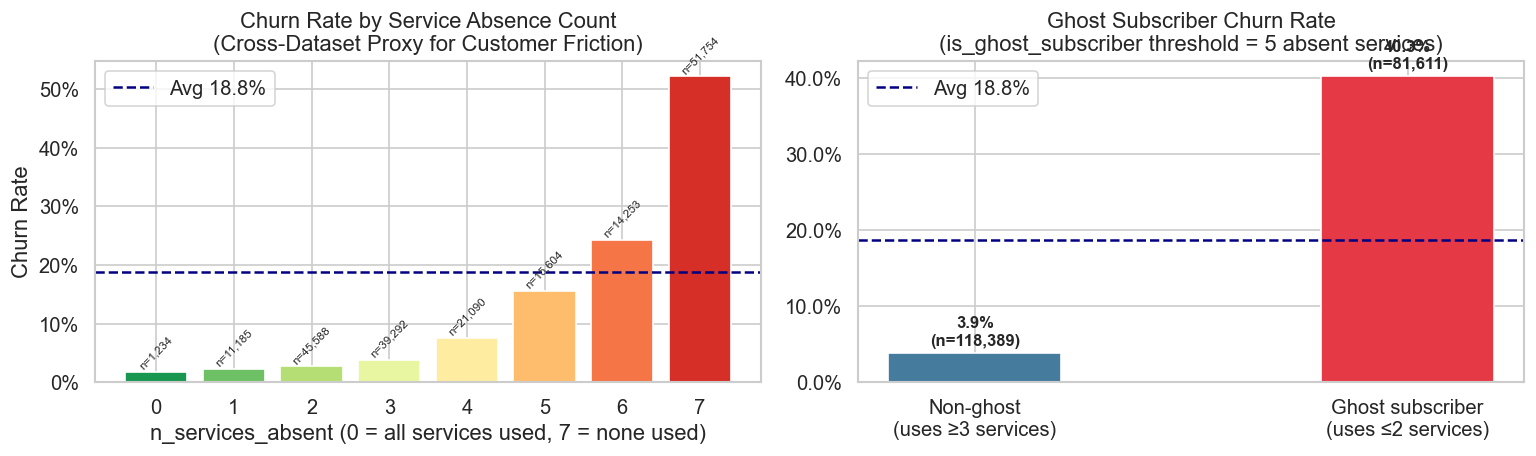

Spearman ρ (n_services_absent ~ CHURN): 0.4706
Spearman ρ (is_ghost_subscriber ~ CHURN): 0.4582


In [5]:
# Apply steps 1 + 2
step2 = ServiceAbsenceEncoder().fit(X1)
X2 = step2.transform(X1)

# Validate: n_services_absent should strongly predict churn
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Churn rate by n_services_absent value
tmp = pd.DataFrame({'n_services_absent': X2['n_services_absent'], 'CHURN': y_train.values})
absence_churn = tmp.groupby('n_services_absent')['CHURN'].agg(['mean', 'count'])
absence_churn.rename(columns={'mean': 'churn_rate', 'count': 'n'}, inplace=True)

bars = axes[0].bar(absence_churn.index, absence_churn['churn_rate'],
                   color=plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(absence_churn))))
axes[0].axhline(y_train.mean(), color='navy', ls='--', lw=1.5, label=f'Avg {y_train.mean():.1%}')
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[0].set_xlabel('n_services_absent (0 = all services used, 7 = none used)')
axes[0].set_ylabel('Churn Rate')
axes[0].set_title('Churn Rate by Service Absence Count\n(Cross-Dataset Proxy for Customer Friction)')
axes[0].legend()
for bar, n in zip(bars, absence_churn['n']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'n={n:,}', ha='center', fontsize=7, rotation=45)

# Ghost subscriber breakdown
ghost_churn = tmp.assign(is_ghost=X2['is_ghost_subscriber'].values).groupby('is_ghost')['CHURN'].mean()
axes[1].bar(['Non-ghost\n(uses ≥3 services)', 'Ghost subscriber\n(uses ≤2 services)'],
            ghost_churn.values,
            color=[PALETTE['retain'], PALETTE['churn']], edgecolor='white', width=0.4)
axes[1].axhline(y_train.mean(), color='navy', ls='--', lw=1.5, label=f'Avg {y_train.mean():.1%}')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[1].set_title(f'Ghost Subscriber Churn Rate\n(is_ghost_subscriber threshold = {step2.GHOST_THRESHOLD} absent services)')
axes[1].legend()
for i, (v, n) in enumerate(zip(ghost_churn.values, tmp.groupby(X2['is_ghost_subscriber'].values)['CHURN'].count())):
    axes[1].text(i, v + 0.01, f'{v:.1%}\n(n={n:,})', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print('Spearman ρ (n_services_absent ~ CHURN):',
      round(X2['n_services_absent'].corr(y_train, method='spearman'), 4))
print('Spearman ρ (is_ghost_subscriber ~ CHURN):',
      round(X2['is_ghost_subscriber'].corr(y_train, method='spearman'), 4))

### 3.3 Imputation (ZeroImputer + MedianImputer)

In [6]:
step3 = ZeroImputer().fit(X2)
step4 = MedianImputer().fit(X2)  # fit on pre-zero-imputed (still has MAR NaNs)
X3 = step3.transform(X2)
X4 = step4.transform(X3)

# Verify all NaNs resolved
remaining_nulls = X4.isna().sum()
remaining_nulls = remaining_nulls[remaining_nulls > 0]
if len(remaining_nulls):
    print('WARNING — remaining nulls after imputation:')
    print(remaining_nulls)
else:
    print('All NaN values resolved after imputation.')

# Show MedianImputer learned values
print('\nTrain medians stored (used for test imputation):')
for col, med in step4.medians_.items():
    print(f'  {col:20s}: {med:,.2f}')

WARNING — remaining nulls after imputation:
REGION      78979
TOP_PACK    83849
dtype: int64

Train medians stored (used for test imputation):
  MONTANT             : 3,000.00
  FREQUENCE_RECH      : 7.00
  REVENUE             : 3,001.00
  ARPU_SEGMENT        : 1,000.00
  FREQUENCE           : 9.00


### 3.4 NumericFeatureEngineer — New Features

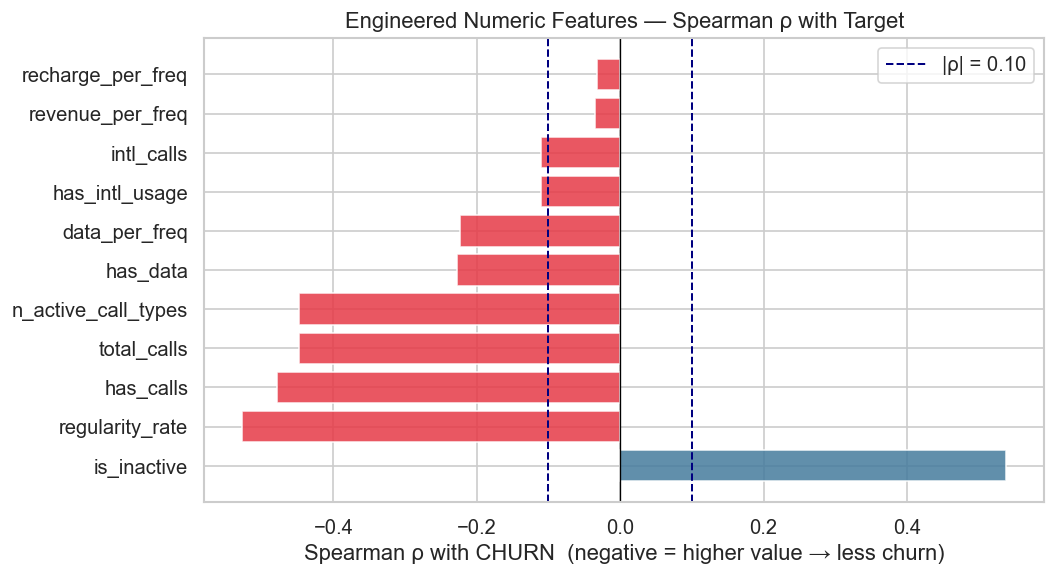

Spearman ρ with CHURN (sorted by |ρ|):
is_inactive            0.5384
regularity_rate       -0.5270
has_calls             -0.4779
total_calls           -0.4475
n_active_call_types   -0.4474
has_data              -0.2276
data_per_freq         -0.2235
has_intl_usage        -0.1107
intl_calls            -0.1106
revenue_per_freq      -0.0350
recharge_per_freq     -0.0322


In [7]:
step5 = NumericFeatureEngineer().fit(X4)
X5 = step5.transform(X4)

new_numeric = [
    'regularity_rate', 'recharge_per_freq', 'revenue_per_freq', 'data_per_freq',
    'total_calls', 'intl_calls', 'n_active_call_types',
    'is_inactive', 'has_data', 'has_calls', 'has_intl_usage',
]

# Show Spearman correlation of each new feature with CHURN
rho = {col: X5[col].corr(y_train, method='spearman') for col in new_numeric}
rho_df = pd.Series(rho).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
colors = [PALETTE['churn'] if v < 0 else PALETTE['retain'] for v in rho_df.values]
ax.barh(rho_df.index, rho_df.values, color=colors, alpha=0.85)
ax.axvline(0, color='black', lw=0.8)
ax.axvline( 0.1, color='navy', ls='--', lw=1.2, label='|ρ| = 0.10')
ax.axvline(-0.1, color='navy', ls='--', lw=1.2)
ax.set_xlabel('Spearman ρ with CHURN  (negative = higher value → less churn)')
ax.set_title('Engineered Numeric Features — Spearman ρ with Target')
ax.legend()
plt.tight_layout()
plt.show()

print('Spearman ρ with CHURN (sorted by |ρ|):')
print(rho_df.round(4).to_string())

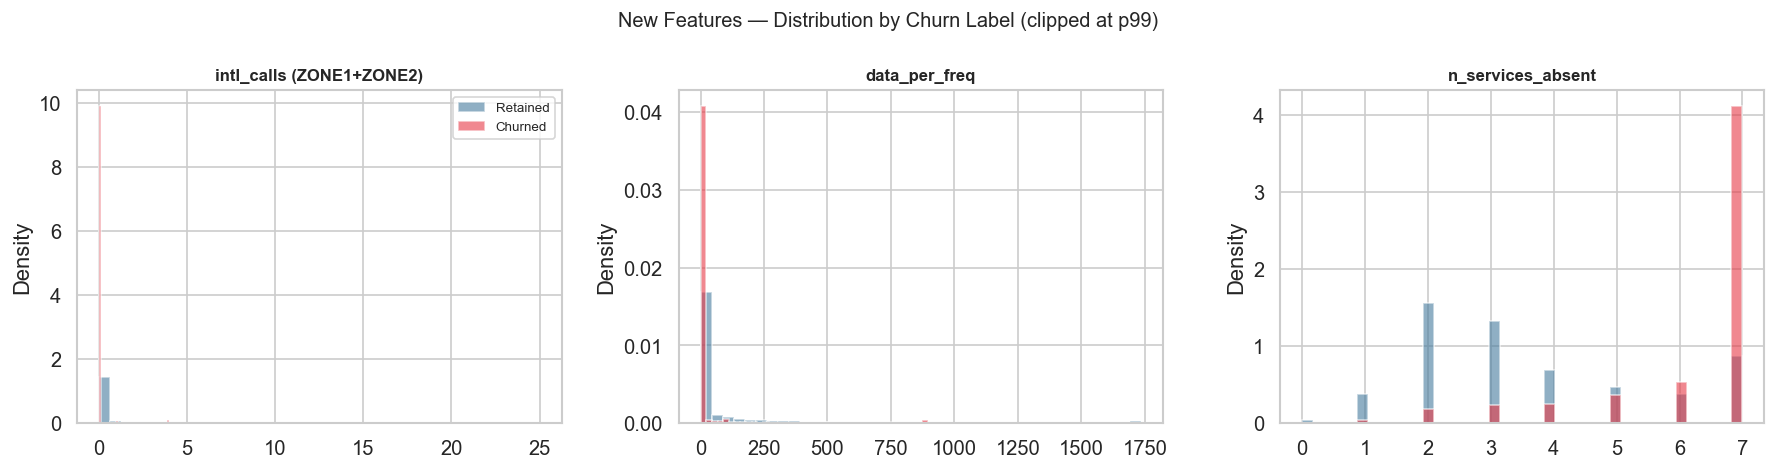

In [8]:
# New feature: intl_calls — validate it's distinct from total_calls
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (feat, label) in zip(axes, [
    ('intl_calls', 'intl_calls (ZONE1+ZONE2)'),
    ('data_per_freq', 'data_per_freq'),
    ('n_services_absent', 'n_services_absent'),
]):
    for churn_val in [0, 1]:
        mask = y_train.values == churn_val
        data = X5[feat].values[mask]
        cap  = np.percentile(data, 99)
        ax.hist(np.clip(data, 0, cap), bins=40, alpha=0.6, density=True,
                color=PALETTE['churn'] if churn_val else PALETTE['retain'],
                label='Churned' if churn_val else 'Retained')
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_ylabel('Density')
    if ax == axes[0]:
        ax.legend(fontsize=8)

plt.suptitle('New Features — Distribution by Churn Label (clipped at p99)', fontsize=12)
plt.tight_layout()
plt.show()

### 3.5 Categorical Encoders (Tenure, MRG, Region, TopPack)

In [9]:
step6 = TenureEncoder().fit(X5)
X6 = step6.transform(X5)
step7 = MRGEncoder().fit(X6)
X7 = step7.transform(X6)
step8 = TargetEncoder(cols=['REGION']).fit(X7, y_train)
X8 = step8.transform(X7)
step9 = TopPackEncoder(min_freq=200).fit(X8, y_train)
X9 = step9.transform(X8)

# Validate REGION_te: should correlate with region-level churn rates from EDA
region_te_corr = X9['REGION_te'].corr(y_train, method='spearman')
print(f'REGION_te Spearman ρ with CHURN : {region_te_corr:.4f}')
print(f'Global mean (target encoder)    : {step8.global_mean_:.4f}')
print(f'\nNumber of TOP_PACK categories kept (freq ≥ 200): {len(step9.keep_packs_)}')
print(f'top_pack_te Spearman ρ with CHURN: {X9["top_pack_te"].corr(y_train, method="spearman"):.4f}')
print(f'tenure_ordinal Spearman ρ       : {X9["tenure_ordinal"].corr(y_train, method="spearman"):.4f}')
print(f'is_new_subscriber Spearman ρ    : {X9["is_new_subscriber"].corr(y_train, method="spearman"):.4f}')

REGION_te Spearman ρ with CHURN : 0.4774
Global mean (target encoder)    : 0.1875

Number of TOP_PACK categories kept (freq ≥ 200): 30
top_pack_te Spearman ρ with CHURN: 0.4113
tenure_ordinal Spearman ρ       : -0.0482
is_new_subscriber Spearman ρ    : nan


## 4. Pre- vs Post-Engineering Signal Comparison

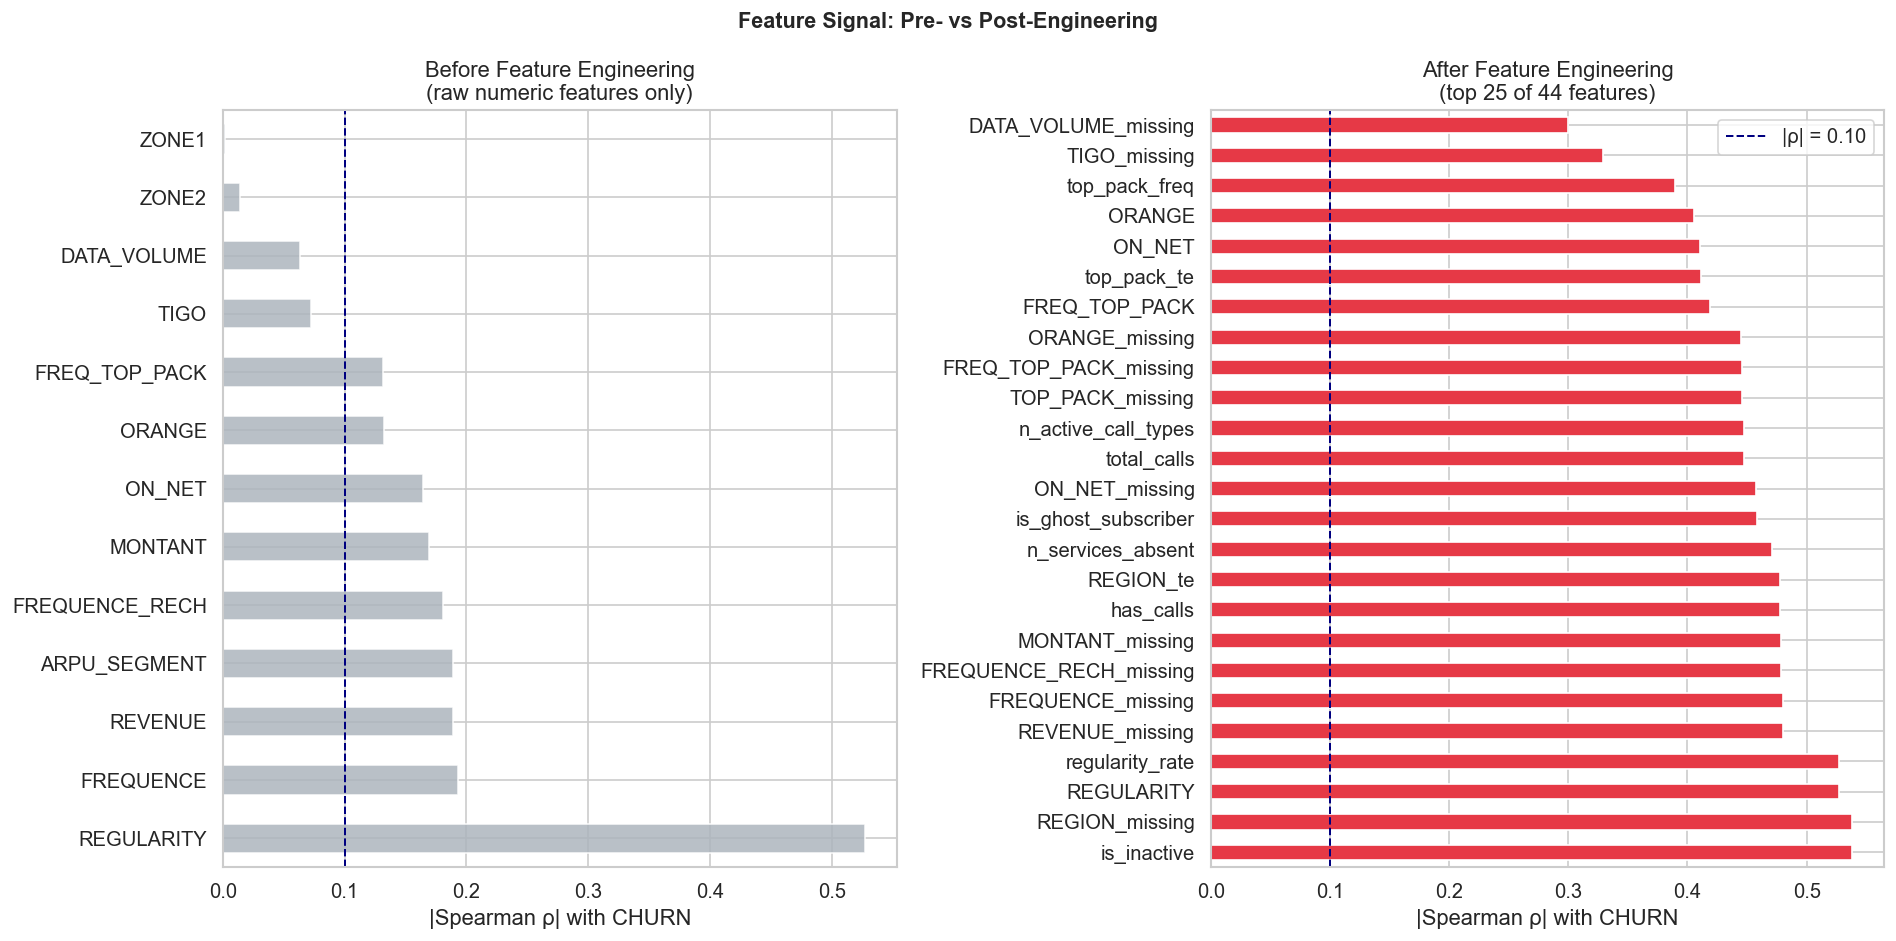

Pre:  max |ρ| = 0.5270 (REGULARITY)
Post: max |ρ| = 0.5384 (is_inactive)
Post: features with |ρ| > 0.10: 32 / 44


In [10]:
# Pre-engineering: Spearman ρ on raw numeric features
raw_num = ['MONTANT', 'FREQUENCE_RECH', 'REVENUE', 'ARPU_SEGMENT', 'FREQUENCE',
           'DATA_VOLUME', 'ON_NET', 'ORANGE', 'TIGO', 'ZONE1', 'ZONE2', 'REGULARITY', 'FREQ_TOP_PACK']

pre_rho = {
    col: X_train[col].corr(y_train, method='spearman')
    for col in raw_num
}

# Post-engineering: Spearman ρ on final feature set
pipeline_full = FeaturePipeline()
X_fe = pipeline_full.fit_transform(X_train, y_train)
feature_cols = get_model_features(X_fe)

post_rho = {
    col: X_fe[col].corr(y_train, method='spearman')
    for col in feature_cols
}

pre_abs  = pd.Series(pre_rho).abs().sort_values(ascending=False)
post_abs = pd.Series(post_rho).abs().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

pre_abs.plot(kind='barh', ax=axes[0], color='#ADB5BD', alpha=0.85)
axes[0].axvline(0.1, color='navy', ls='--', lw=1.2)
axes[0].set_title('Before Feature Engineering\n(raw numeric features only)')
axes[0].set_xlabel('|Spearman ρ| with CHURN')

post_abs.head(25).plot(kind='barh', ax=axes[1],
    color=['#E63946' if v > 0.1 else '#ADB5BD' for v in post_abs.head(25).values])
axes[1].axvline(0.1, color='navy', ls='--', lw=1.2, label='|ρ| = 0.10')
axes[1].set_title('After Feature Engineering\n(top 25 of 44 features)')
axes[1].set_xlabel('|Spearman ρ| with CHURN')
axes[1].legend()

plt.suptitle('Feature Signal: Pre- vs Post-Engineering', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Pre:  max |ρ| = {pre_abs.max():.4f} ({pre_abs.idxmax()})')
print(f'Post: max |ρ| = {post_abs.max():.4f} ({post_abs.idxmax()})')
print(f'Post: features with |ρ| > 0.10: {(post_abs > 0.1).sum()} / {len(post_abs)}')

## 5. Feature Intercorrelation — Post-Engineering

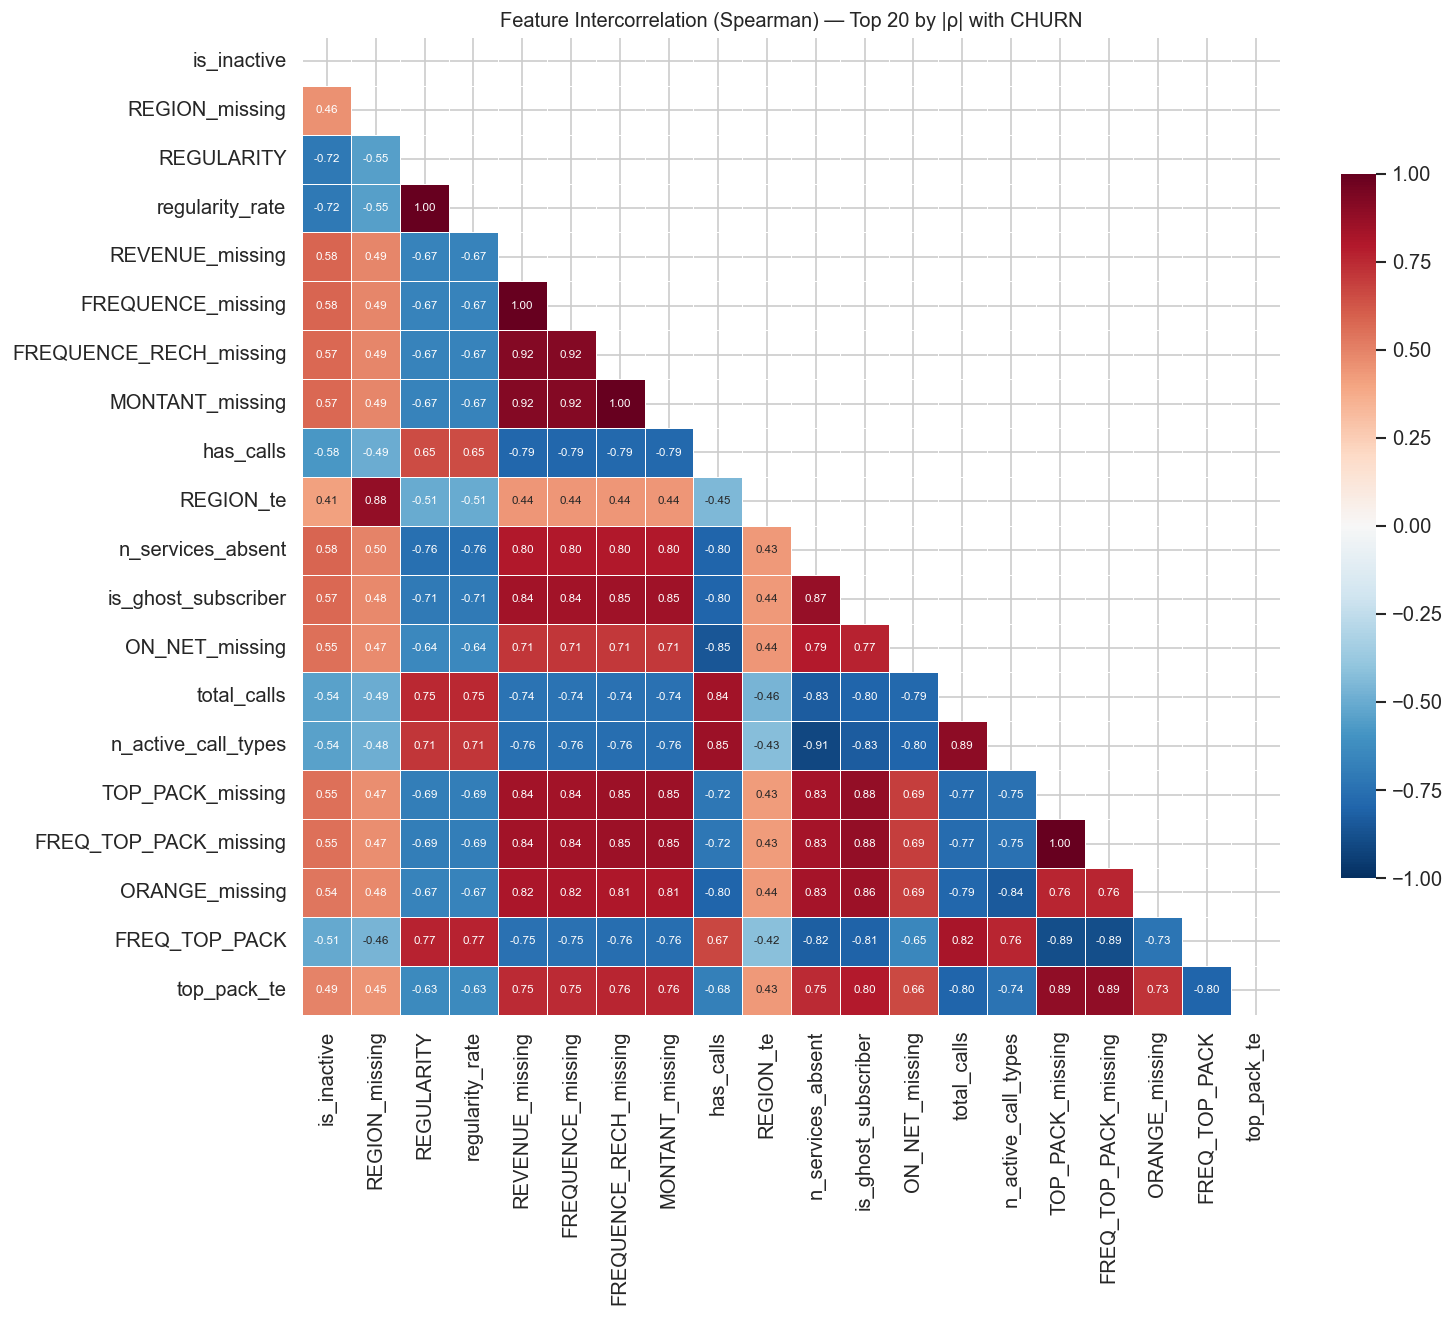

High collinearity pairs (|ρ| ≥ 0.85) — tree models handle these but LR should drop one:


,f1,f2,rho
2,REVENUE_missing,FREQUENCE_missing,1.0000
7,FREQUENCE_RECH_missing,MONTANT_missing,1.0000
20,TOP_PACK_missing,FREQ_TOP_PACK_missing,1.0000
1,REGULARITY,regularity_rate,1.0000
3,REVENUE_missing,FREQUENCE_RECH_missing,0.9220
4,REVENUE_missing,MONTANT_missing,0.9220
5,FREQUENCE_missing,FREQUENCE_RECH_missing,0.9220
6,FREQUENCE_missing,MONTANT_missing,0.9220
15,n_services_absent,n_active_call_types,-0.9070
19,total_calls,n_active_call_types,0.8920


In [11]:
# Focus on top 20 most signal-rich features
top20 = post_abs.head(20).index.tolist()
corr_matrix = X_fe[top20].corr(method='spearman')

fig, ax = plt.subplots(figsize=(13, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.3,
    cbar_kws={'shrink': 0.7}, ax=ax,
    annot_kws={'size': 7},
)
ax.set_title('Feature Intercorrelation (Spearman) — Top 20 by |ρ| with CHURN', fontsize=12)
plt.tight_layout()
plt.show()

# Flag high collinearity pairs
high_pairs = []
for i, c1 in enumerate(top20):
    for c2 in top20[i+1:]:
        r = corr_matrix.loc[c1, c2]
        if abs(r) >= 0.85:
            high_pairs.append({'f1': c1, 'f2': c2, 'rho': round(r, 3)})

if high_pairs:
    print('High collinearity pairs (|ρ| ≥ 0.85) — tree models handle these but LR should drop one:')
    display(pd.DataFrame(high_pairs).sort_values('rho', key=abs, ascending=False))
else:
    print('No high collinearity pairs found at |ρ| ≥ 0.85 in top-20 features.')

## 6. Leakage Check

In [12]:
# The pipeline was fit on X_train. Apply it to test — test statistics should differ.
X_test_fe = pipeline_full.transform(test_raw)
test_cols  = get_model_features(X_test_fe)

# Columns must match exactly
assert feature_cols == test_cols, 'Feature columns differ between train and test!'
print(f'Column match: OK  ({len(feature_cols)} features in both splits)')

# Statistics should differ (test uses TRAIN medians/encodings, but test data differs)
comparison = pd.DataFrame({
    'train_mean': X_fe[feature_cols].mean(),
    'test_mean':  X_test_fe[feature_cols].mean(),
}).assign(abs_diff=lambda d: (d['train_mean'] - d['test_mean']).abs())

# Leakage would show as near-zero diff on learned features (target-encoded)
print('\nTarget-encoded features — mean should differ between train and test:')
print(comparison.loc[['REGION_te', 'top_pack_te', 'top_pack_freq']].round(4))

print('\nMedian-imputed features — test uses train medians but has different distributions:')
print(comparison.loc[['MONTANT', 'REVENUE', 'FREQUENCE']].round(4))

print('\nTop 5 largest mean differences (confirms distributions differ across splits):')
print(comparison.sort_values('abs_diff', ascending=False).head(5).round(4))

Column match: OK  (44 features in both splits)

Target-encoded features — mean should differ between train and test:
               train_mean  test_mean  abs_diff
REGION_te          0.1875     0.1871    0.0004
top_pack_te        0.1875     0.1869    0.0006
top_pack_freq      0.2117     0.2111    0.0006

Median-imputed features — test uses train medians but has different distributions:
           train_mean  test_mean  abs_diff
MONTANT     4670.3208  4641.1528   29.1680
REVENUE     4686.6011  4662.4224   24.1787
FREQUENCE     12.3502    12.2966    0.0535

Top 5 largest mean differences (confirms distributions differ across splits):
               train_mean  test_mean  abs_diff
MONTANT         4670.3208  4641.1528   29.1680
REVENUE         4686.6011  4662.4224   24.1787
DATA_VOLUME     1719.1782  1699.6624   19.5159
data_per_freq    137.7800   133.0529    4.7271
ON_NET           175.6554   177.2124    1.5570


## 7. Decision Tree Importance — Post-Engineering

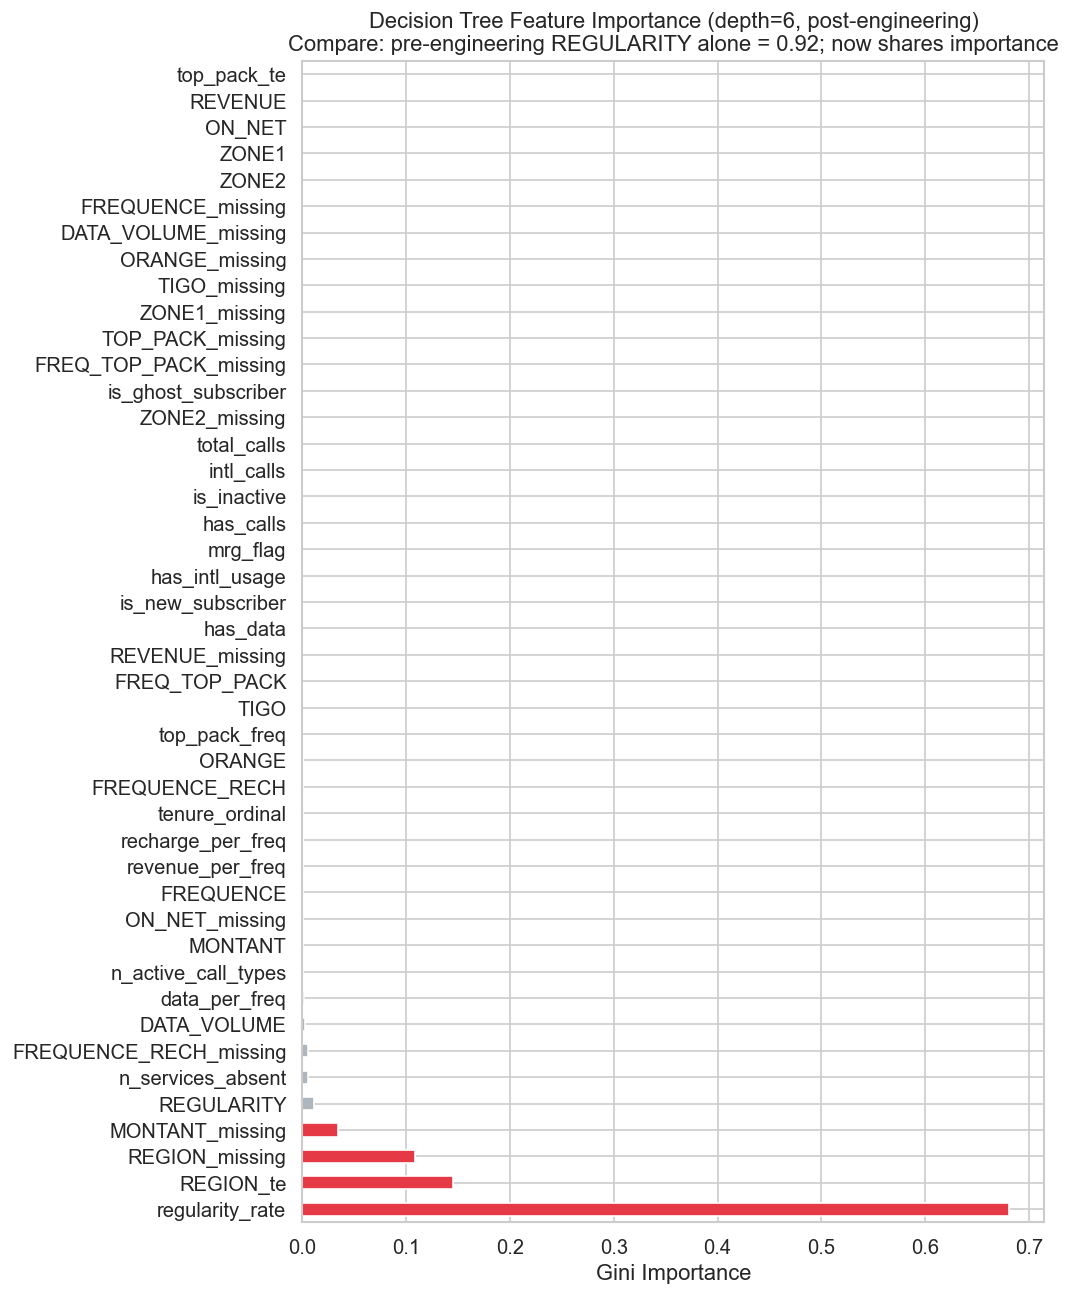

Top 15 features by Gini importance:
regularity_rate          0.6808
REGION_te                0.1450
REGION_missing           0.1089
MONTANT_missing          0.0346
REGULARITY               0.0112
n_services_absent        0.0056
FREQUENCE_RECH_missing   0.0052
DATA_VOLUME              0.0022
data_per_freq            0.0018
n_active_call_types      0.0010
MONTANT                  0.0007
ON_NET_missing           0.0006
FREQUENCE                0.0005
revenue_per_freq         0.0003
recharge_per_freq        0.0003


In [13]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

dt = Pipeline([
    ('imp', SimpleImputer(strategy='median')),
    ('clf', DecisionTreeClassifier(max_depth=6, random_state=RANDOM_STATE)),
])
dt.fit(X_fe[feature_cols], y_train)

imp = pd.Series(
    dt.named_steps['clf'].feature_importances_,
    index=feature_cols,
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 11))
imp.plot(
    kind='barh', ax=ax,
    color=['#E63946' if v > 0.02 else '#ADB5BD' for v in imp.values]
)
ax.set_xlabel('Gini Importance')
ax.set_title('Decision Tree Feature Importance (depth=6, post-engineering)\n'
             'Compare: pre-engineering REGULARITY alone = 0.92; now shares importance')
plt.tight_layout()
plt.show()

print('Top 15 features by Gini importance:')
print(imp.head(15).round(4).to_string())

## 8. Final Feature Manifest

In [14]:
feature_descriptions = {
    # Missing indicators
    'REGION_missing':        'Region not recorded (MNAR: 39.4% missing; lift 2.5×)',
    'MONTANT_missing':       'No recharge amount data (MAR; churn lift 8.8×)',
    'FREQUENCE_RECH_missing':'No recharge frequency data (MAR; collinear with MONTANT_missing)',
    'REVENUE_missing':       'No revenue data (MAR; churn lift 8.3×)',
    'FREQUENCE_missing':     'No transaction frequency (MAR; collinear with REVENUE_missing)',
    'DATA_VOLUME_missing':   'Never used data service (MNAR; lift 4.2×)',
    'ON_NET_missing':        'Never called same-network (MNAR; lift 8.1×)',
    'ORANGE_missing':        'Never called Orange subscribers (MNAR; lift 9.8×)',
    'TIGO_missing':          'Never called Tigo subscribers (MNAR; lift 9.5×)',
    'ZONE1_missing':         'No international Zone 1 calls (MNAR; lift 4.5×)',
    'ZONE2_missing':         'No international Zone 2 calls (MNAR; lift 4.5×)',
    'TOP_PACK_missing':      'No active data/call bundle (MNAR; lift 9.7×)',
    'FREQ_TOP_PACK_missing': 'TOP_PACK frequency unavailable (collinear with TOP_PACK_missing)',
    # Service absence (new)
    'n_services_absent':     '[NEW] Count of MNAR service flags that were originally missing [0–7]',
    'is_ghost_subscriber':   '[NEW] 1 if ≥5 service channels absent — cross-dataset friction proxy',
    # Raw usage (post-imputation)
    'MONTANT':               'Total recharge amount (XOF); median-imputed',
    'FREQUENCE_RECH':        'Number of recharges; median-imputed',
    'REVENUE':               'Monthly revenue (XOF); median-imputed',
    'FREQUENCE':             'Number of transactions; median-imputed',
    'DATA_VOLUME':           'Data usage (MB); zero-imputed (MNAR)',
    'ON_NET':                'Calls to same-operator subs; zero-imputed',
    'ORANGE':                'Calls to Orange subs; zero-imputed',
    'TIGO':                  'Calls to Tigo subs; zero-imputed',
    'ZONE1':                 'International Zone 1 calls; zero-imputed',
    'ZONE2':                 'International Zone 2 calls; zero-imputed',
    'REGULARITY':            'Days active in 90-day window [0, 90] — dominant predictor',
    'FREQ_TOP_PACK':         'TOP_PACK usage frequency; zero-imputed',
    # Engineered numeric
    'regularity_rate':       'REGULARITY / 90.0 — normalised activity ratio [0, 1]',
    'recharge_per_freq':     'MONTANT / (FREQUENCE_RECH + 1) — recharge value per event',
    'revenue_per_freq':      'REVENUE / (FREQUENCE + 1) — revenue per transaction',
    'data_per_freq':         '[NEW] DATA_VOLUME / (FREQUENCE + 1) — data intensity per transaction',
    'total_calls':           'Sum of all call columns — aggregate call volume',
    'intl_calls':            '[NEW] ZONE1 + ZONE2 — international call volume',
    'n_active_call_types':   'Count of non-zero call channels [0–5]',
    'is_inactive':           'REGULARITY < 5 — extreme inactivity flag',
    'has_data':              'DATA_VOLUME > 0 — data service adopted',
    'has_calls':             'total_calls > 0 — any call activity',
    'has_intl_usage':        '[NEW] intl_calls > 0 — international usage indicator',
    # Categorical encodings
    'tenure_ordinal':        'TENURE ordinal [0–10]; -1 for unknown',
    'is_new_subscriber':     'TENURE in {A < 2 month, B 2 month}',
    'mrg_flag':              'MRG == YES → 1 (VAS subscription)',
    'REGION_te':             'James–Stein smoothed target encoding of REGION',
    'top_pack_freq':         'Fraction of train subscribers using this TOP_PACK',
    'top_pack_te':           'Smoothed churn rate of this TOP_PACK bucket',
}

manifest = pd.DataFrame({
    'feature': feature_cols,
    'spearman_rho': [post_rho[f] for f in feature_cols],
    'abs_rho': [abs(post_rho[f]) for f in feature_cols],
    'dt_gini': [imp.get(f, 0.0) for f in feature_cols],
    'description': [feature_descriptions.get(f, '—') for f in feature_cols],
}).sort_values('abs_rho', ascending=False)

print(f'Total model features: {len(feature_cols)}')
print(f'  - Features with |ρ| > 0.10 : {(manifest["abs_rho"] > 0.10).sum()}')
print(f'  - Features with |ρ| > 0.05 : {(manifest["abs_rho"] > 0.05).sum()}')
print(f'  - New features (this session): 5 (n_services_absent, is_ghost_subscriber, intl_calls, has_intl_usage, data_per_freq)')
print()
display(manifest[['feature', 'spearman_rho', 'dt_gini', 'description']].round(4))

Total model features: 44
  - Features with |ρ| > 0.10 : 32
  - Features with |ρ| > 0.05 : 39
  - New features (this session): 5 (n_services_absent, is_ghost_subscriber, intl_calls, has_intl_usage, data_per_freq)



,feature,spearman_rho,dt_gini,description
34,is_inactive,0.5384,0.0000,REGULARITY < 5 — extreme inactivity flag
12,REGION_missing,0.5379,0.1089,Region not recorded (MNAR: 39.4% missing; lift 2.5×)
10,REGULARITY,-0.5270,0.0112,"Days active in 90-day window [0, 90] — dominant predictor"
27,regularity_rate,-0.5270,0.6808,"REGULARITY / 90.0 — normalised activity ratio [0, 1]"
15,REVENUE_missing,0.4798,0.0001,No revenue data (MAR; churn lift 8.3×)
16,FREQUENCE_missing,0.4798,0.0000,No transaction frequency (MAR; collinear with REVENUE_missing)
14,FREQUENCE_RECH_missing,0.4784,0.0052,No recharge frequency data (MAR; collinear with MONTANT_missing)
13,MONTANT_missing,0.4784,0.0346,No recharge amount data (MAR; churn lift 8.8×)
36,has_calls,-0.4779,0.0000,total_calls > 0 — any call activity
41,REGION_te,0.4774,0.1450,James–Stein smoothed target encoding of REGION


In [15]:
# Confirm saved artifacts exist
from pathlib import Path
features_dir = Path('../data/features')
for f in ['train_features.parquet', 'test_features.parquet', 'feature_pipeline.pkl',
          'feature_stats.csv', 'feature_manifest.json']:
    p = features_dir / f
    status = f'{p.stat().st_size / 1024 / 1024:.1f} MB' if p.exists() else 'MISSING'
    print(f'  {f:35s} {status}')

# Quick sanity on parquet
train_pq = pd.read_parquet(features_dir / 'train_features.parquet')
print(f'\ntrain_features.parquet: {train_pq.shape[0]:,} rows × {train_pq.shape[1]} cols')
print(f'Null rate: {train_pq.isna().mean().mean():.6f}')
print(f'Churn rate: {train_pq["CHURN"].mean():.4f}')

  train_features.parquet              54.2 MB
  test_features.parquet               23.3 MB
  feature_pipeline.pkl                0.0 MB
  feature_stats.csv                   0.0 MB
  feature_manifest.json               0.0 MB

train_features.parquet: 2,154,048 rows × 45 cols
Null rate: 0.000000
Churn rate: 0.1875
